In [1]:
import os
import sys
from pathlib import Path

# Use the notebook's folder as the working directory (portable across machines).
nb_file = globals().get("__vsc_ipynb_file__")
PROJECT_ROOT = Path(nb_file).resolve().parent if nb_file else Path.cwd().resolve()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import time
import warnings
warnings.filterwarnings('ignore')

from features import load_dataset, image_db_to_arrays, NeuralNetwork

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

Chargement de Ensemble_B...
DEBUG load_dataset: 5 echantillon(s) aleatoire(s)
--------------------------------------------------------------------------------
Index: 2043
Classe: Diamant2 (label=2)
One-hot: (0, 0, 1, 0, 0, 0, 0, 0)
Fichier: Ensemble_B/Diamant2/240Diamant2.png
Raw[0:10]: [208 208 208 209 210 210 210 207 198 180]
Pixels[0:10]: [0.8157 0.816  0.8179 0.8212 0.8221 0.8113 0.7729 0.7002 0.6178 0.5626]


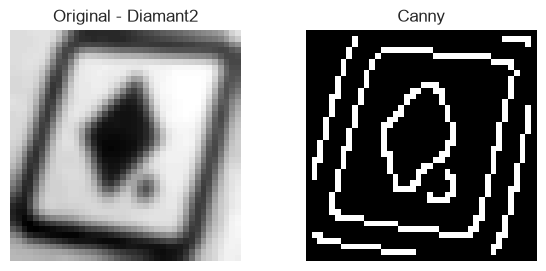

--------------------------------------------------------------------------------
Index: 2842
Classe: Hexagone2 (label=4)
One-hot: (0, 0, 0, 0, 1, 0, 0, 0)
Fichier: Ensemble_B/Hexagone2/505Hexagone2.png
Raw[0:10]: [116 107  84  59  39  28  24  24  24  24]
Pixels[0:10]: [0.4242 0.3584 0.2562 0.1646 0.1148 0.0999 0.0981 0.0972 0.0957 0.0976]


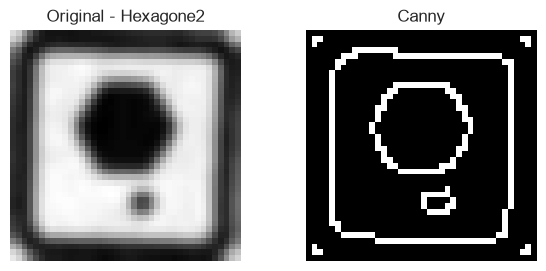

--------------------------------------------------------------------------------
Index: 938
Classe: Cercle2 (label=0)
One-hot: (1, 0, 0, 0, 0, 0, 0, 0)
Fichier: Ensemble_B/Cercle2/938_Cercle2.png
Raw[0:10]: [78 65 42 28 24 23 22 21 21 21]
Pixels[0:10]: [0.2671 0.205  0.136  0.1016 0.0931 0.0892 0.0871 0.0881 0.0925 0.0967]


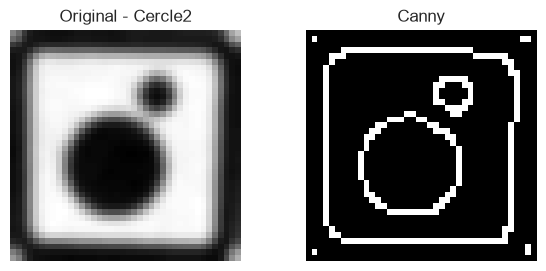

--------------------------------------------------------------------------------
Index: 3802
Classe: Hexagone5 (label=5)
One-hot: (0, 0, 0, 0, 0, 1, 0, 0)
Fichier: Ensemble_B/Hexagone5/377Hexagone5.png
Raw[0:10]: [163 154 131 106  86  73  66  63  62  61]
Pixels[0:10]: [0.6006 0.5333 0.4285 0.3318 0.2713 0.2434 0.2327 0.228  0.2253 0.2253]


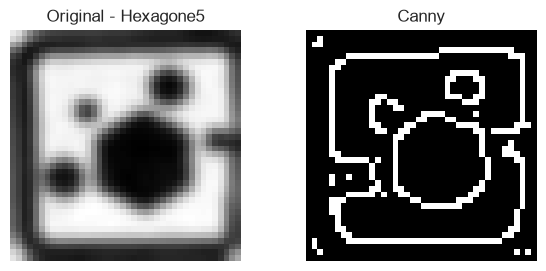

--------------------------------------------------------------------------------
Index: 586
Classe: Cercle2 (label=0)
One-hot: (1, 0, 0, 0, 0, 0, 0, 0)
Fichier: Ensemble_B/Cercle2/111_Cercle2.png
Raw[0:10]: [24 24 23 22 21 21 22 23 25 28]
Pixels[0:10]: [0.0997 0.1008 0.1005 0.0995 0.1024 0.1096 0.1205 0.134  0.1447 0.1535]


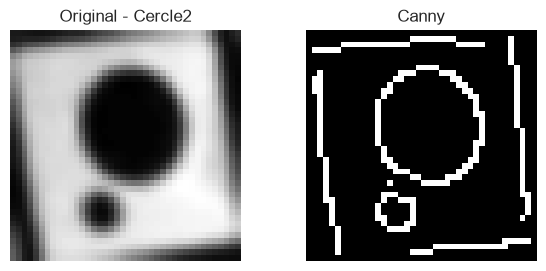

image_db contient 8 classes
5685 images, 1024 features, 8 classes
   Classes: ['Cercle2', 'Cercle5', 'Diamant2', 'Diamant5', 'Hexagone2', 'Hexagone5', 'Triangle2', 'Triangle5']


In [2]:
DATA_DIR = 'Ensemble_B'
IMAGE_SHAPE = (32, 32)
RANDOM_STATE = 0

print(f'Chargement de {DATA_DIR}...')
Xpix, y_flat, class_names, image_db = load_dataset(
    DATA_DIR,
    image_shape=IMAGE_SHAPE,
    debug_samples=5,
    debug_seed=5,
    show_debug_images=True,
    return_image_db=True,
)

if Xpix is None:
    raise RuntimeError('Aucune image chargee')

X, y = image_db_to_arrays(image_db)
if X is None:
    raise RuntimeError('image_db vide apres conversion')

D = X.shape[1]  # Nombre de features
C = len(class_names)  # Nombre de classes

print(f'image_db contient {len(image_db)} classes')
print(f'{X.shape[0]} images, {D} features, {C} classes')
print(f'   Classes: {class_names}')

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
print(X_train_scaled.shape)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}')

(4548, 1024)
Train: 4548, Test: 1137


In [4]:
results = {}

models_sklearn = {
    'SVM': SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE),
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'RN_sklearn': MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, random_state=RANDOM_STATE)
}

print('Entraînement des modeles sklearn...')
for name, model in models_sklearn.items():
    print(f'  {name}...', end=' ', flush=True)
    
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - t0
    
    t1 = time.time()
    y_pred = model.predict(X_test_scaled)
    predict_time = time.time() - t1
    acc = accuracy_score(y_test, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        'y_pred': y_pred,
        'accuracy': acc,
        'precision': p,
        'recall': r,
        'f1': f,
        'train_time': train_time,
        'predict_time': predict_time,
        'cm': cm
    }
    
    print(f'Acc={acc:.2%}')

print('\nModeles sklearn entraînes!')

Entraînement des modeles sklearn...
  SVM... Acc=95.25%
  kNN... Acc=92.96%
  RN_sklearn... Acc=96.92%

Modeles sklearn entraînes!


In [37]:
#TODO entraintement du reseau de neurones maison
nn = NeuralNetwork(
    input_size = 1024,
    hidden_size = 20,
    output_size = 8,
    hidden_layers = 2
)
t0 = time.time()
nn.train(X_train_scaled, y_train, nb_iteration=3000)
t1 = time.time()
train_time = t1 - t0
t0 = time.time()
y_pred_nn = nn.predict(X_test_scaled)
t1 = time.time()
predict_time = t1 - t0


# Pour validation et test
print(y_test)
acc_nn = accuracy_score(y_test, y_pred_nn)
p_nn, r_nn, f_nn, _ = precision_recall_fscore_support(y_test, y_pred_nn, average='macro', zero_division=0)
cm_nn = confusion_matrix(y_test, y_pred_nn)

results['Réseau_Maison'] = {
    'y_pred': y_pred_nn,
    'accuracy': acc_nn,
    'precision': p_nn,
    'recall': r_nn,
    'f1': f_nn,
    'train_time': train_time,
    'predict_time': predict_time,
    'cm': cm_nn
}

print()
print(f'Test: Acc={acc_nn:.2%}, Train time={train_time:.3f}s')

Iteration 100/3000, Loss: 1.0233
Iteration 200/3000, Loss: 0.7227
Iteration 300/3000, Loss: 0.5732
Iteration 400/3000, Loss: 0.4814
Iteration 500/3000, Loss: 0.4121
Iteration 600/3000, Loss: 0.3577
Iteration 700/3000, Loss: 0.3155
Iteration 800/3000, Loss: 0.2815
Iteration 900/3000, Loss: 0.2556
Iteration 1000/3000, Loss: 0.2353
Iteration 1100/3000, Loss: 0.2190
Iteration 1200/3000, Loss: 0.2053
Iteration 1300/3000, Loss: 0.1936
Iteration 1400/3000, Loss: 0.1833
Iteration 1500/3000, Loss: 0.1742
Iteration 1600/3000, Loss: 0.1661
Iteration 1700/3000, Loss: 0.1588
Iteration 1800/3000, Loss: 0.1521
Iteration 1900/3000, Loss: 0.1459
Iteration 2000/3000, Loss: 0.1402
Iteration 2100/3000, Loss: 0.1349
Iteration 2200/3000, Loss: 0.1300
Iteration 2300/3000, Loss: 0.1253
Iteration 2400/3000, Loss: 0.1210
Iteration 2500/3000, Loss: 0.1170
Iteration 2600/3000, Loss: 0.1133
Iteration 2700/3000, Loss: 0.1098
Iteration 2800/3000, Loss: 0.1065
Iteration 2900/3000, Loss: 0.1033
Iteration 3000/3000, Lo

In [38]:
print('\n' + '='*90)
print('COMPARAISON DES 4 MODELES')
print('='*90)

summary_data = []
for name, res in results.items():
    summary_data.append({
        'Modèle': name,
        'Accuracy': f'{res["accuracy"]:.1%}',
        'Précision': f'{res["precision"]:.3f}',
        'Rappel': f'{res["recall"]:.3f}',
        'F1': f'{res["f1"]:.3f}',
        'Entraînement (s)': f'{res["train_time"]:.4f}',
        'Prédiction (ms)': f'{res["predict_time"]*1000:.2f}'
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print('='*90)


COMPARAISON DES 4 MODELES
       Modèle Accuracy Précision Rappel    F1 Entraînement (s) Prédiction (ms)
          SVM    95.3%     0.953  0.953 0.953           1.0057         1773.12
          kNN    93.0%     0.924  0.929 0.924           0.0009           57.23
   RN_sklearn    96.9%     0.964  0.966 0.965           1.5357            1.30
Réseau_Maison    95.7%     0.950  0.956 0.953          17.9991            0.55


## 7. Matrices de Confusion

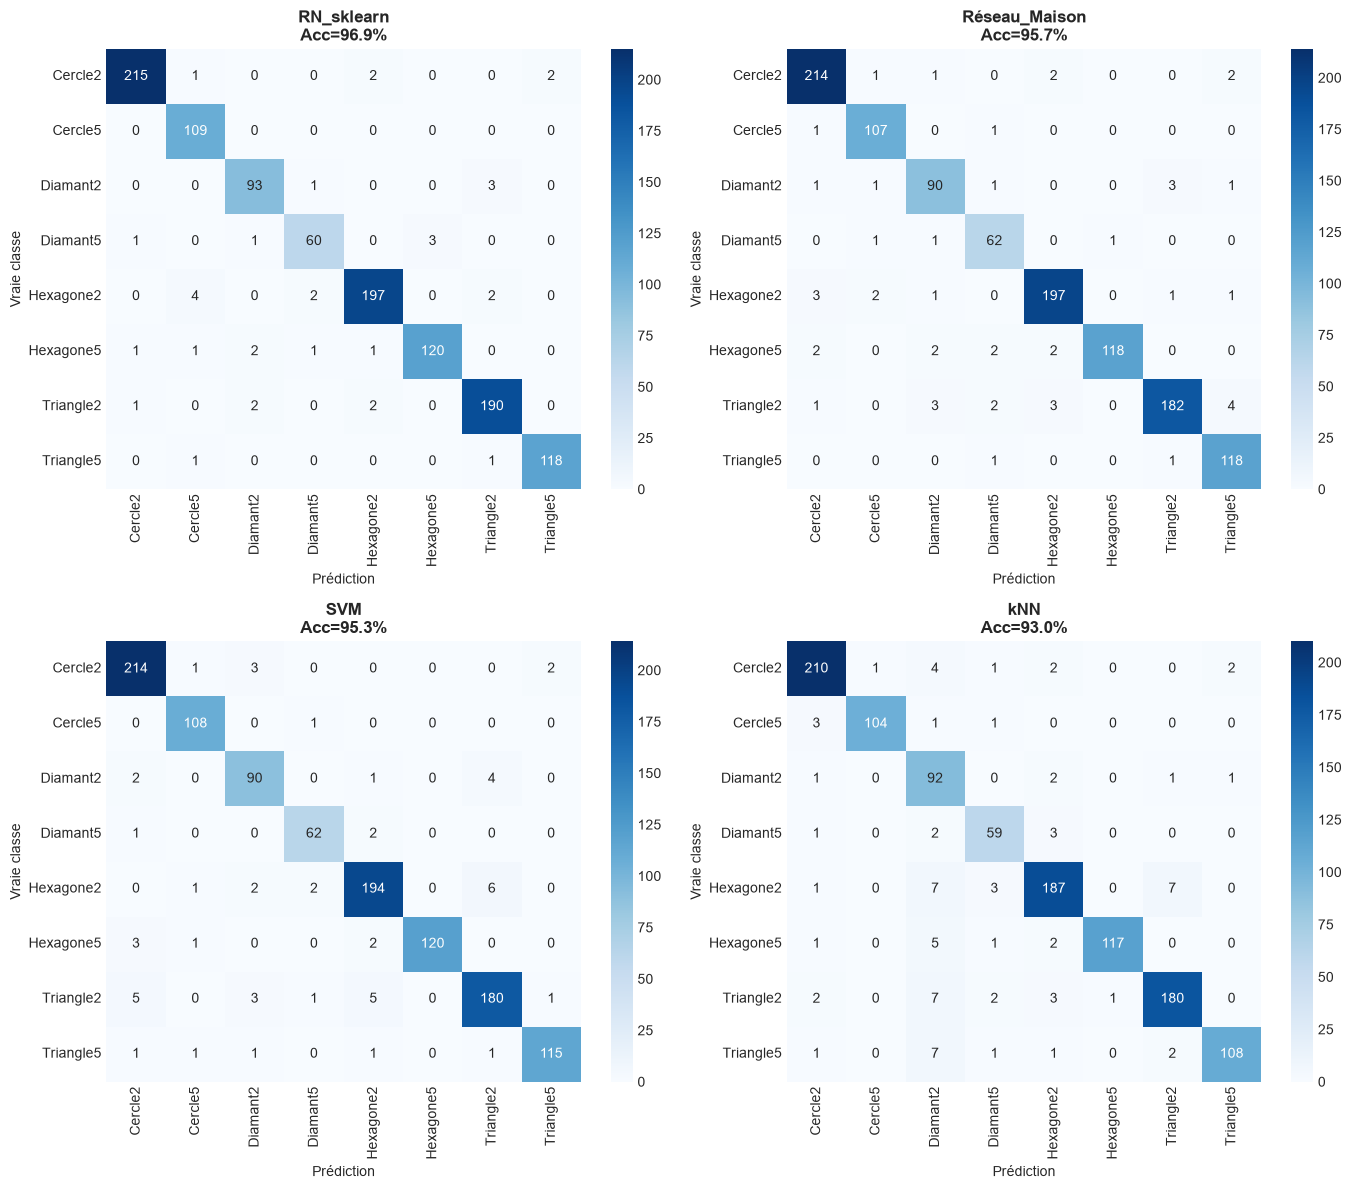

Matrices de confusion sauvegardees


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, res) in enumerate(sorted(results.items())):
    ax = axes[idx]
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{model_name}\nAcc={res["accuracy"]:.1%}', 
                fontsize=12, fontweight='bold')
    ax.set_ylabel('Vraie classe')
    ax.set_xlabel('Prédiction')

plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Matrices de confusion sauvegardees')

## 8. Graphes Comparatifs

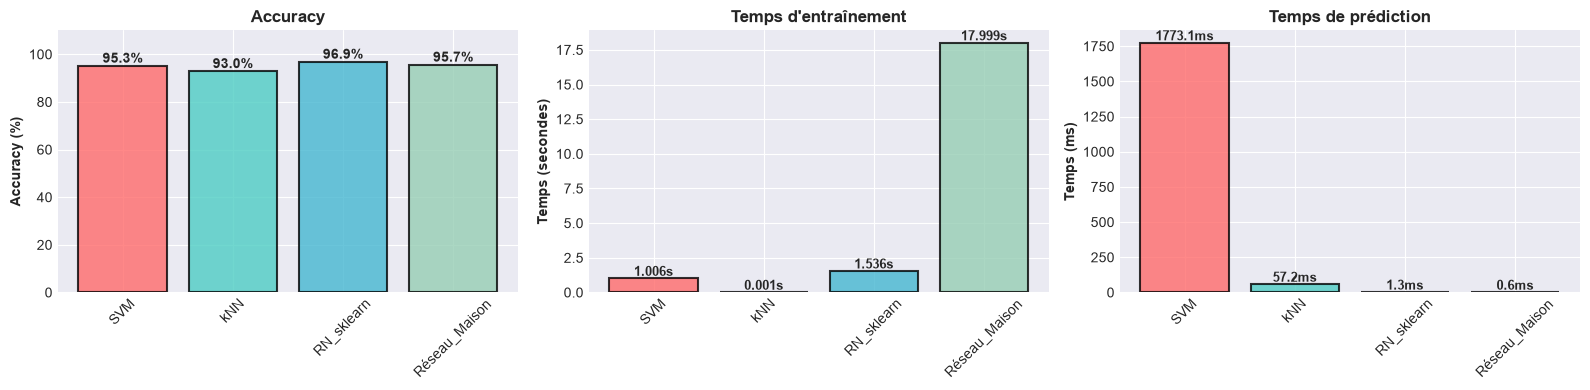

Graphes comparatifs sauvegardés


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Accuracy
models_list = list(results.keys())
accuracies = [results[m]['accuracy']*100 for m in models_list]
train_times = [results[m]['train_time'] for m in models_list]
pred_times = [results[m]['predict_time']*1000 for m in models_list]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Accuracy
ax = axes[0]
bars = ax.bar(models_list, accuracies, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
           ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Accuracy', fontsize=12, fontweight='bold')
ax.set_ylim([0, 110])
ax.tick_params(axis='x', rotation=45)

# Temps d'entraînement
ax = axes[1]
bars = ax.bar(models_list, train_times, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}s',
           ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_ylabel('Temps (secondes)', fontweight='bold')
ax.set_title('Temps d\'entraînement', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# Temps de prédiction
ax = axes[2]
bars = ax.bar(models_list, pred_times, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}ms',
           ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_ylabel('Temps (ms)', fontweight='bold')
ax.set_title('Temps de prédiction', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('comparison_graphs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Graphes comparatifs sauvegardés')

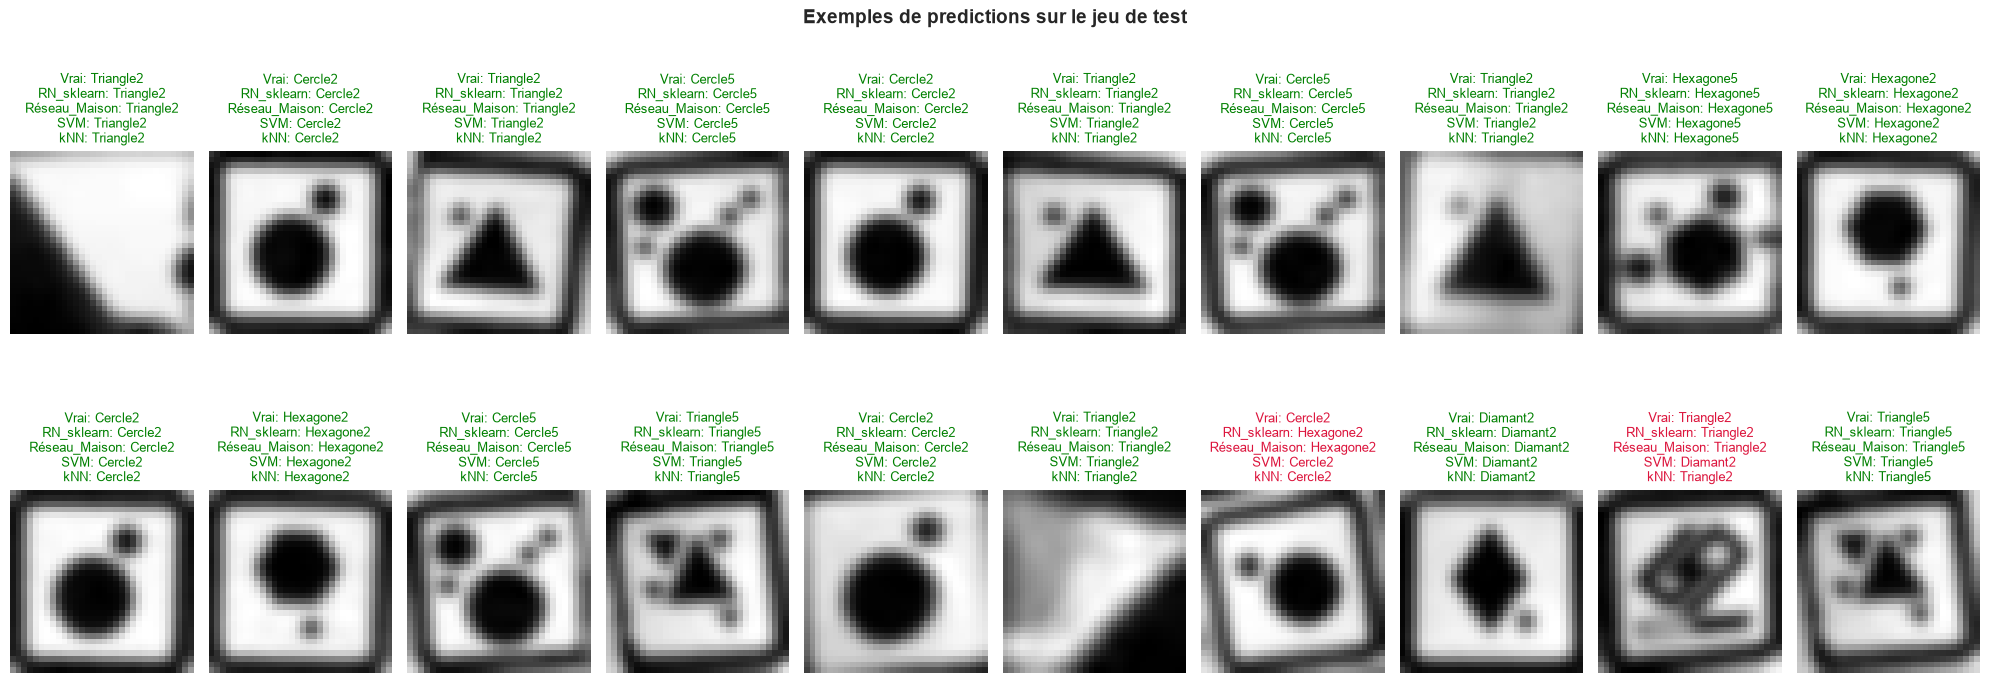

In [41]:
# 9. Exemples de predictions
n_examples = 20
rng = np.random.default_rng(70)

pix_dim = int(np.prod(IMAGE_SHAPE))
idxs = rng.choice(len(y_test), size=min(n_examples, len(y_test)), replace=False)

fig, axes = plt.subplots(2, 10, figsize=(20, 8))
axes = np.array(axes).reshape(-1)

for k, i in enumerate(idxs):
    ax = axes[k]
    img = X_test[i, :pix_dim].reshape(IMAGE_SHAPE)

    true_label = class_names[y_test[i]]
    preds = {name: class_names[res['y_pred'][i]] for name, res in results.items()}

    # On met un check rapide pour voir si tous les modeles sont d'accord avec la vraie classe.
    all_correct = all(p == true_label for p in preds.values())
    color = 'green' if all_correct else 'crimson'

    lignes = [f"Vrai: {true_label}"] + [f"{name}: {pred}" for name, pred in sorted(preds.items())]

    ax.imshow(img, cmap='gray')
    ax.set_title("\n".join(lignes), fontsize=9, color=color)
    ax.axis('off')

# Cache les axes restants si n_examples < 8
for j in range(len(idxs), len(axes)):
    axes[j].axis('off')

plt.suptitle('Exemples de predictions sur le jeu de test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()